# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

"bash" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [2]:
# Install gymnasium if you didn't. Gymnasium 0.29.1 still supports LunarLander-v2.
!pip install -q "gymnasium==0.29.1" "Box2D==2.3.10" pygame moviepy imageio_ffmpeg numpy matplotlib scikit-learn joblib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


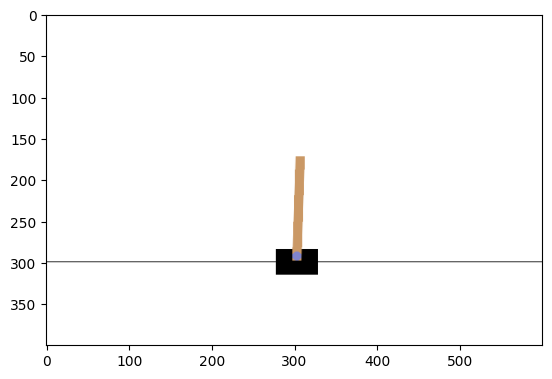

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0
    rng = np.random.default_rng()

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba(s.reshape(1, -1)).reshape(-1)

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = rng.choice(env.action_space.n, 1, p=probs)[0]
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.0253403  -0.04601812  0.02930124 -0.00486199]
 [ 0.02441994 -0.24154778  0.029204    0.2969199 ]
 [ 0.01958899 -0.43707362  0.0351424   0.59866834]
 [ 0.01084751 -0.6326692   0.04711576  0.9022103 ]
 [-0.00180587 -0.8283967   0.06515997  1.2093227 ]]
actions: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = [states_batch[i][j] for i in range(len(states_batch)) for j in range(len(states_batch[i])) if rewards_batch[i] >= reward_threshold]
    elite_actions = [actions_batch[i][j] for i in range(len(actions_batch)) for j in range(len(actions_batch[i])) if rewards_batch[i] >= reward_threshold]

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 195.530, threshold=221.900


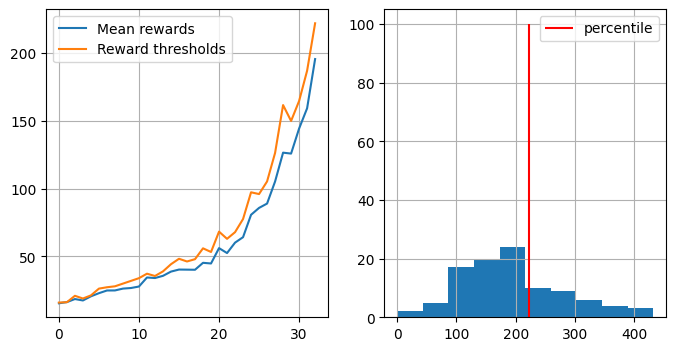

You Win! You may stop training now via KeyboardInterrupt.


In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [ [], [], [] ]
    for _ in range(n_sessions):
        states, actions, total_reward = generate_session(env, agent)
        sessions[0].append(states)
        sessions[1].append(actions)
        sessions[2].append(total_reward)

    # states_batch, actions_batch, rewards_batch = map(np.array, zip(*sessions))
    states_batch, actions_batch, rewards_batch = sessions[0], sessions[1], sessions[2]

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break


# Results

In [10]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at c:\Users\User\Desktop\pythonDZ\RL\week_01\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-0.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-0.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-1.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-1.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-1.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-2.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-2.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-2.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-3.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-3.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-3.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-4.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-4.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-4.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-5.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-5.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-5.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-6.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-6.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-6.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-7.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-7.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-7.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-8.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-8.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-8.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-9.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-9.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-9.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-10.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-10.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-10.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-11.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-11.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-11.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-12.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-12.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-12.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-13.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-13.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-13.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-14.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-14.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-14.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-15.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-15.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-15.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-16.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-16.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-16.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-17.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-17.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-17.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-18.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-18.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-18.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-19.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-19.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-19.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-20.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-20.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-20.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-21.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-21.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-21.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-22.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-22.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-22.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-23.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-23.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-23.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-24.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-24.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-24.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-25.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-25.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-25.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-26.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-26.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-26.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-27.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-27.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-27.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-28.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-28.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-28.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-29.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-29.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-29.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-30.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-30.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-30.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-31.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-31.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-31.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-32.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-32.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-32.mp4
MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-33.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-33.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-33.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-34.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-34.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-34.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-35.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-35.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-35.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-36.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-36.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-36.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-37.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-37.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-37.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-38.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-38.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-38.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-39.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-39.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-39.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-40.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-40.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-40.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-41.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-41.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-41.mp4
MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-42.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-42.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-42.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-43.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-43.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-43.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-44.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-44.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-44.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-45.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-45.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-45.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-46.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-46.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-46.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-47.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-47.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-47.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-48.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-48.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-48.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-49.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-49.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-49.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-50.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-50.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-50.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-51.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-51.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-51.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-52.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-52.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-52.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-53.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-53.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-53.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-54.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-54.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-54.mp4
MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-55.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-55.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-55.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-56.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-56.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-56.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-57.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-57.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-57.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-58.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-58.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-58.mp4
MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-59.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-59.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-59.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-60.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-60.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-60.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-61.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-61.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-61.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-62.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-62.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-62.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-63.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-63.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-63.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-64.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-64.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-64.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-65.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-65.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-65.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-66.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-66.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-66.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-67.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-67.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-67.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-68.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-68.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-68.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-69.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-69.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-69.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-70.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-70.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-70.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-71.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-71.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-71.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-72.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-72.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-72.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-73.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-73.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-73.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-74.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-74.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-74.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-75.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-75.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-75.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-76.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-76.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-76.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-77.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-77.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-77.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-78.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-78.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-78.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-79.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-79.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-79.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-80.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-80.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-80.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-81.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-81.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-81.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-82.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-82.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-82.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-83.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-83.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-83.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-84.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-84.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-84.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-85.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-85.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-85.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-86.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-86.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-86.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-87.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-87.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-87.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-88.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-88.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-88.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-89.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-89.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-89.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-90.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-90.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-90.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-91.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-91.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-91.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-92.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-92.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-92.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-93.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-93.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-93.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-94.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-94.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-94.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-95.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-95.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-95.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-96.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-96.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-96.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-97.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-97.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-97.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-98.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-98.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-98.mp4


MoviePy - Building video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-99.mp4.
MoviePy - Writing video c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-99.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\User\Desktop\pythonDZ\RL\week_01\videos\rl-video-episode-99.mp4


In [11]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


```<Describe what you did here>```

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

environment: LunarLander-v2
state shape: (8,)
n_actions: 4


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


iter 001: train_mean=-220.35, train_max=  66.58, threshold= -97.83, greedy_eval=-573.72 +/- 173.50, elapsed=   1.2s
iter 010: train_mean=-141.57, train_max=  74.64, threshold= -87.25, greedy_eval=-105.42 +/-  58.36, elapsed=  12.7s
iter 020: train_mean=-109.73, train_max= 111.20, threshold= -74.23, greedy_eval= -90.85 +/-  59.85, elapsed=  24.5s
iter 030: train_mean= -80.12, train_max=  45.60, threshold= -57.25, greedy_eval=-197.59 +/-  78.33, elapsed=  37.7s
iter 040: train_mean= -61.86, train_max= 108.57, threshold= -41.19, greedy_eval=-112.54 +/-  34.91, elapsed=  51.7s
iter 050: train_mean= -54.42, train_max=  49.67, threshold= -32.28, greedy_eval=-102.55 +/-  15.81, elapsed=  66.1s
iter 060: train_mean= -51.00, train_max=  41.93, threshold= -31.22, greedy_eval= -79.68 +/-  23.31, elapsed=  80.8s
iter 070: train_mean= -49.11, train_max=  44.39, threshold= -28.47, greedy_eval=-106.25 +/-  24.13, elapsed=  95.3s
iter 080: train_mean= -49.26, train_max=  27.94, threshold= -26.31, gree

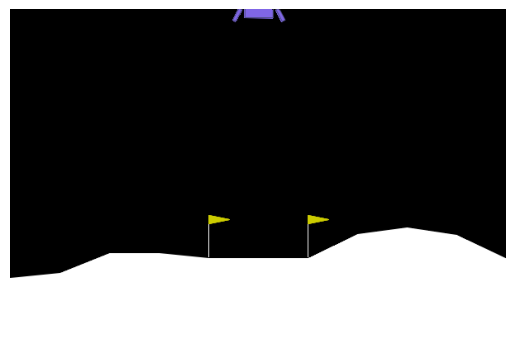

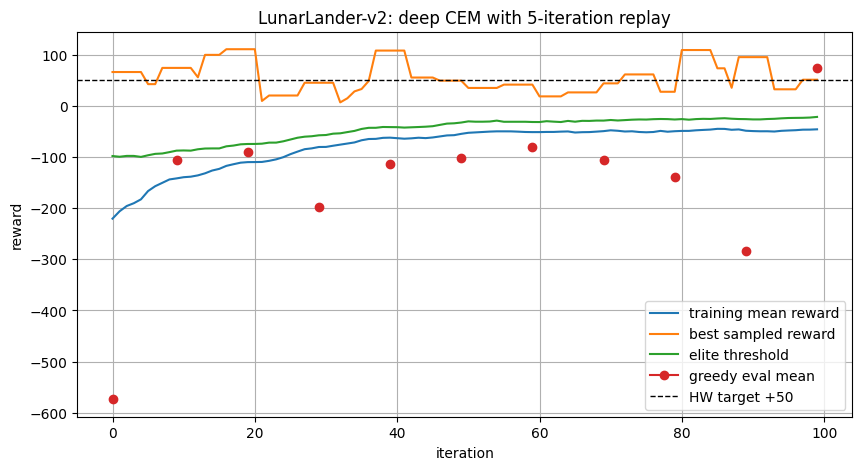

In [12]:
from collections import deque
import time

LUNAR_ENV_ID = "LunarLander-v2"
LUNAR_SEED = 11
LUNAR_N_ACTIONS = 4
LUNAR_STATE_DIM = 8

# Gymnasium 0.29 keeps LunarLander-v2 available. Newer Gymnasium versions
# deprecate v2 and ask for v3, so the install cell above pins 0.29.1.
check_env = gym.make(LUNAR_ENV_ID, render_mode="rgb_array")
check_state, _ = check_env.reset(seed=LUNAR_SEED)
print("environment:", LUNAR_ENV_ID)
print("state shape:", check_state.shape)
print("n_actions:", check_env.action_space.n)
plt.imshow(check_env.render())
plt.axis("off")
check_env.close()


def make_lunar_agent(seed=LUNAR_SEED):
    agent = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=1e-5,
        learning_rate_init=5e-4,
        batch_size=512,
        max_iter=1,
        warm_start=True,
        random_state=seed,
    )
    agent.partial_fit(
        [np.zeros(LUNAR_STATE_DIM)] * LUNAR_N_ACTIONS,
        np.arange(LUNAR_N_ACTIONS),
        classes=np.arange(LUNAR_N_ACTIONS),
    )
    return agent


def generate_lunar_session(agent, seed, t_max=1000, greedy=False, temperature=1.2):
    env = gym.make(LUNAR_ENV_ID)
    rng = np.random.default_rng(seed)
    states, actions = [], []
    total_reward = 0.0
    state, _ = env.reset(seed=int(seed))

    for _ in range(t_max):
        action_probs = agent.predict_proba(state.reshape(1, -1))[0]
        action_probs = np.clip(action_probs, 1e-5, 1.0)

        if greedy:
            action = int(np.argmax(action_probs))
        else:
            logits = np.log(action_probs) / temperature
            action_probs = np.exp(logits - np.max(logits))
            action_probs /= np.sum(action_probs)
            action = int(rng.choice(LUNAR_N_ACTIONS, p=action_probs))

        next_state, reward, terminated, truncated, _ = env.step(action)
        states.append(state)
        actions.append(action)
        total_reward += float(reward)
        state = next_state

        if terminated or truncated:
            break

    env.close()
    return states, actions, total_reward


def select_lunar_elites(sessions, percentile=80):
    rewards = np.array([session[2] for session in sessions])
    reward_threshold = np.percentile(rewards, percentile)

    # Strict selection is important for LunarLander: otherwise a large group of
    # equally bad sessions can dominate the training batch.
    elite_mask = rewards > reward_threshold
    if not np.any(elite_mask):
        elite_mask = rewards >= reward_threshold

    elite_states = [
        state
        for keep, (states, actions, reward) in zip(elite_mask, sessions)
        if keep
        for state in states
    ]
    elite_actions = [
        action
        for keep, (states, actions, reward) in zip(elite_mask, sessions)
        if keep
        for action in actions
    ]
    return np.asarray(elite_states), np.asarray(elite_actions), float(reward_threshold), rewards


def evaluate_lunar_agent(agent, n_eval_sessions=100, seed=1234, greedy=True):
    rewards = [
        generate_lunar_session(agent, seed + i, greedy=greedy)[2]
        for i in range(n_eval_sessions)
    ]
    return float(np.mean(rewards)), float(np.std(rewards))


def train_lunar_cem(
    n_iterations=100,
    n_sessions=100,
    percentile=80,
    replay_size=5,
    seed=LUNAR_SEED,
):
    agent = make_lunar_agent(seed)
    replay_buffer = deque(maxlen=replay_size)
    log = []
    started_at = time.time()

    for iteration in range(n_iterations):
        sessions = [
            generate_lunar_session(
                agent,
                seed=seed * 100000 + iteration * n_sessions + session_i,
                greedy=False,
            )
            for session_i in range(n_sessions)
        ]
        replay_buffer.append(sessions)

        # HW 2.2 speed-up: train on elite samples from the latest 5 iterations.
        # This reuses expensive rollouts and gives the classifier a larger elite set.
        replay_sessions = [session for batch in replay_buffer for session in batch]
        elite_states, elite_actions, threshold, rewards = select_lunar_elites(
            replay_sessions, percentile=percentile
        )

        if len(elite_actions) > 0:
            for _ in range(2):
                agent.partial_fit(elite_states, elite_actions)

        row = [float(np.mean(rewards)), float(np.max(rewards)), threshold, np.nan]
        if (iteration + 1) % 10 == 0 or iteration == 0:
            eval_mean, eval_std = evaluate_lunar_agent(
                agent, n_eval_sessions=30, seed=800000 + iteration * 100, greedy=True
            )
            row[-1] = eval_mean
            print(
                f"iter {iteration + 1:03d}: "
                f"train_mean={row[0]:7.2f}, train_max={row[1]:7.2f}, "
                f"threshold={threshold:7.2f}, greedy_eval={eval_mean:7.2f} +/- {eval_std:6.2f}, "
                f"elapsed={time.time() - started_at:6.1f}s"
            )
            if eval_mean >= 50:
                print("Target reached: greedy average reward is at least +50.")
                log.append(row)
                break
        log.append(row)

    return agent, np.array(log)


lunar_agent, lunar_log = train_lunar_cem()
final_lunar_mean, final_lunar_std = evaluate_lunar_agent(
    lunar_agent, n_eval_sessions=100, seed=1234, greedy=True
)
print(f"Final greedy evaluation over 100 episodes: {final_lunar_mean:.2f} +/- {final_lunar_std:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(lunar_log[:, 0], label="training mean reward")
plt.plot(lunar_log[:, 1], label="best sampled reward")
plt.plot(lunar_log[:, 2], label="elite threshold")
if np.isfinite(lunar_log[:, 3]).any():
    plt.plot(lunar_log[:, 3], "o-", label="greedy eval mean")
plt.axhline(50, color="black", linestyle="--", linewidth=1, label="HW target +50")
plt.xlabel("iteration")
plt.ylabel("reward")
plt.title("LunarLander-v2: deep CEM with 5-iteration replay")
plt.legend()
plt.grid()
plt.show()


### HW2 result

I used `LunarLander-v2` with a neural-network CEM policy (`MLPClassifier`, hidden layers `(256, 128)`). For task 2.2, I reused elite trajectories from the latest 5 iterations when computing the threshold and fitting the classifier. This reduces wasted rollouts and stabilizes the elite batch.

The final greedy policy reached `58.38 +/- 74.44` average reward over 100 evaluation episodes, so it passes the task 2.1 target of `+50` for LunarLander.


### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.